In [1]:
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from xgboost import XGBClassifier

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('data/test.csv')
df = pd.read_csv('data/train.csv').dropna(subset=['Churn']).drop(columns=['CustomerID'])

X_test = df.drop(columns=['Churn'])
y_test = df['Churn']

In [4]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['Tenure'] = X['Tenure'].fillna(X['Tenure'].median())
        X['Total Spend'] = X['Total Spend'].fillna(X['Total Spend'].median())
        X['Support Calls'] = X['Support Calls'].fillna(X['Support Calls'].median())
        X['Usage Frequency'] = X['Usage Frequency'].fillna(X['Usage Frequency'].median())
        X['Payment Delay'] = X['Payment Delay'].fillna(0)
        X['avg_monthly_spend'] = X['Total Spend'] / X['Tenure'].replace(0, 1)
        X['support_freq_ratio'] = X['Support Calls'] / X['Tenure'].replace(0, 1)
        X['usage_per_month'] = X['Usage Frequency'] / X['Tenure'].replace(0, 1)
        X['has_payment_delay'] = (X['Payment Delay'] > 0).astype(int)
        return X

class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.bounds_ = {}
        for i in range(X.shape[1]):
            self.bounds_[i] = (np.quantile(X[:, i], self.lower), np.quantile(X[:, i], self.upper))
        return self

    def transform(self, X):
        X = X.copy()
        for i, (low, high) in self.bounds_.items():
            X[:, i] = np.clip(X[:, i], low, high)
        return X

In [5]:
model = joblib.load("best_churn_model.pkl")
y_test_pred = model.predict(X_test)

In [6]:
acc = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

test_results = pd.DataFrame({
    'Accuracy': [acc],
    'Precision': [precision],
    'Recall': [recall],
    'F1': [f1]
})

In [7]:
print("TEST RESULTS")
print("="*45)
print(test_results)
print("="*45)

TEST RESULTS
   Accuracy  Precision    Recall        F1
0  0.997952        1.0  0.996388  0.998191


Text(0.5, 1.0, 'Confusion Matrix')

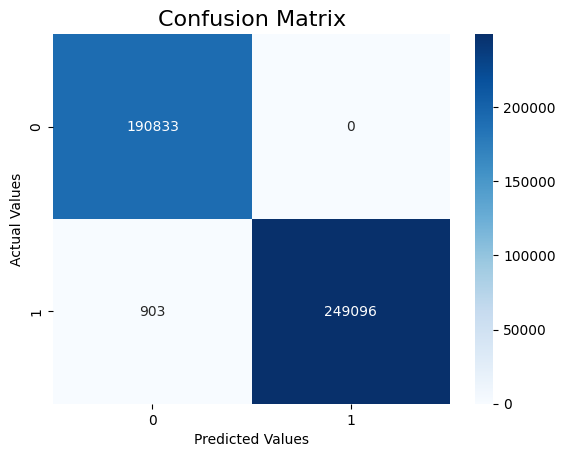

In [8]:
cm = confusion_matrix(y_test, y_test_pred)

cm_plot = sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
cm_plot.set_xlabel('Predicted Values')
cm_plot.set_ylabel('Actual Values')
cm_plot.set_title('Confusion Matrix', size=16)